# Stacked Compton-$y$ at DES Y3 mass-map peaks: full analysis walkthrough

**Companion notebook to the Paper-3B data release.** It reproduces every
figure and headline number of the analysis from the frozen data products in
the release bundle, and records the design decisions in the order they were
made.

**How to run** — download and unpack the data-product bundle
(`paper3b_products_v1`, ~30 MB), then:

```bash
export PAPER3B_PRODUCTS=/path/to/paper3b_products_v1
jupyter nbconvert --to notebook --execute paperB_walkthrough.ipynb
```

Requirements: `python >= 3.10`, `numpy`, `scipy`, `matplotlib`. Nothing here
imports the analysis package — the notebook is intentionally self-contained
so the numbers can be checked without installing anything else. Every input
file is integrity-checked against the bundle manifest, and the four
*measurement-freeze* files are additionally pinned to the hashes signed
before any model comparison (§2).

**What is / is not recomputed here.** All statistics are *loaded* from the
frozen products and re-plotted; the notebook re-derives only cheap
diagnostics (CAP photometry on stacked images, $\chi^2$ against the model
tables). The expensive stages — map downloads, peak finding on the maps, the
23k-peak stacks, the 61-unit mock grids, the fits — ran on the Flatiron
clusters; §7 records exactly what ran where, with job IDs and code
provenance.

In [1]:
import hashlib, json, os
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

ROOT = Path(os.environ.get("PAPER3B_PRODUCTS",
            "/mnt/home/mlee1/ceph/paper3/B/release_bundle/paper3b_products_v1"))
assert ROOT.exists(), f"set PAPER3B_PRODUCTS to the bundle directory (got {ROOT})"
FIG = Path("figures_paperB"); FIG.mkdir(exist_ok=True)

# Okabe-Ito colour-blind-safe palette
OI = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
      "red": "#D55E00", "purple": "#CC79A7", "sky": "#56B4E9", "grey": "#999999"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 10})

def sha256(p):
    return hashlib.sha256(Path(p).read_bytes()).hexdigest()

def load(rel):
    p = ROOT / rel
    got = sha256(p)
    want = MANIFEST["files"][rel]["sha256"]
    assert got == want, f"bundle integrity failure: {rel}"
    return np.load(p, allow_pickle=True) if p.suffix == ".npz" else json.load(open(p))

MANIFEST = json.load(open(ROOT / "MANIFEST.json"))
print(f"bundle {MANIFEST['version']}: {len(MANIFEST['files'])} files")

# The four measurement-freeze files, pinned 2026-07-17 BEFORE any model
# comparison. The analysis code refuses to load them on any mismatch; the
# same gate travels with this bundle.
for rel, want in MANIFEST["frozen_hashes"].items():
    assert sha256(ROOT / rel) == want, f"FREEZE HASH MISMATCH: {rel}"
    print(f"freeze-verified  {rel}  {want[:12]}…")

bundle paper3b_products_v1: 63 files
freeze-verified  wp2_measurement/stack_wiener_sm2am_fid.npz  1b5450693240…
freeze-verified  wp2_measurement/stack_glimpse_sm2am_fid.npz  0cef5a5b251a…
freeze-verified  wp3_nulls/sigma_sys_wiener_decomposed.npz  b53e5bb65839…
freeze-verified  wp3_nulls/sigma_sys_glimpse_decomposed.npz  60f5cfef6f1d…


## 1. Survey data, footprint, and the peak catalogs

**Inputs** (public; not bundled — see each release page):

| dataset | role | reference |
|---|---|---|
| DES Y3 convergence maps (Wiener + GLIMPSE, full + 4 tomographic bins) | peak positions | Jeffrey et al. 2021 (arXiv:2105.13539) |
| ACT DR6 Compton-$y$ ILC map (+ CIB-deprojected variants) | the stacked signal | ACT collaboration DR6 |
| ACT DR5 SZ cluster catalog | absolute units/beam anchor (§3) | Hilton et al. (arXiv:2009.11043) |
| DES Y3 2pt n(z) (MagLim) | mock source-plane weighting (§4) | DES Y3 data release |

**Decision — map variant.** The *Wiener* reconstruction is the headline
map: it is the standard posterior-mean estimator for cross-correlation
work, with well-understood (Gaussian-prior) noise suppression. *GLIMPSE*
(sparsity prior) preserves individual high-S/N peaks but suppresses
low-significance maxima non-linearly; it is carried through the entire
chain as a cross-check, never as the headline.

**Decision — peak definition** (applied identically to data and mocks):
mask **before** smoothing (zero-fill outside the harmonized DES×ACT
footprint), Gaussian smoothing in harmonic space at the fiducial
$\sigma = 2'$ (robustness set $\{1,2,5,8\}'$), a peak = pixel strictly
above all HEALPix neighbours, and
$\nu = (\kappa_{\rm sm}-\bar\kappa)/\sigma_{\kappa}$ **self-normalized on
the map's own footprint statistics** (this makes the whole chain exactly
invariant under any multiplicative map rescaling — the shear $m$-bias
closure of §6 rests on it). Peaks within $2\sigma_{\rm sm}$ of the footprint
edge are excluded.

         catalog  n peaks  excluded  nu>=4  map sigma
    wiener sm2am    28730      3065     86  2.431e-03
   glimpse sm2am     8897      1380    269  2.312e-03


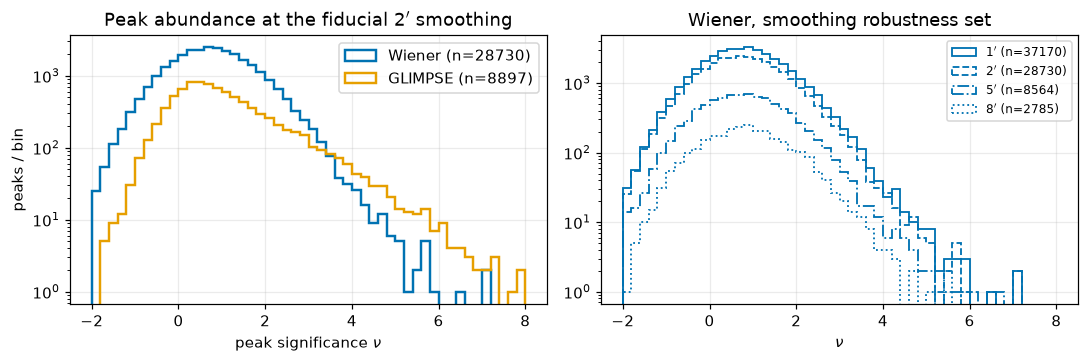

In [2]:
pk_w = load("wp1_maps/peaks_wiener_sm2am.npz")
pk_g = load("wp1_maps/peaks_glimpse_sm2am.npz")
fp_json = load("wp1_maps/peak_catalog_summary.json")

print(f"{'catalog':>16} {'n peaks':>8} {'excluded':>9} {'nu>=4':>6}  map sigma")
rows = []
for name, pk in (("wiener sm2am", pk_w), ("glimpse sm2am", pk_g)):
    rows.append((name, len(pk["nu"]), int(pk["n_excluded"]),
                 int((pk["nu"] >= 4).sum()), float(pk["map_sigma"])))
    print(f"{name:>16} {rows[-1][1]:8d} {rows[-1][2]:9d} {rows[-1][3]:6d}  {rows[-1][4]:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
bins = np.linspace(-2, 8, 51)
axes[0].hist(pk_w["nu"], bins=bins, histtype="step", lw=1.6, color=OI["blue"],
             label=f"Wiener (n={len(pk_w['nu'])})")
axes[0].hist(pk_g["nu"], bins=bins, histtype="step", lw=1.6, color=OI["orange"],
             label=f"GLIMPSE (n={len(pk_g['nu'])})")
axes[0].set(yscale="log", xlabel=r"peak significance $\nu$", ylabel="peaks / bin",
            title="Peak abundance at the fiducial 2$'$ smoothing")
axes[0].legend()
for s, ls in zip((1, 2, 5, 8), ("-", "--", "-.", ":")):
    p = load(f"wp1_maps/peaks_wiener_sm{s}am.npz")
    axes[1].hist(p["nu"], bins=bins, histtype="step", lw=1.2, ls=ls,
                 color=OI["blue"], label=f"{s}$'$ (n={len(p['nu'])})")
axes[1].set(yscale="log", xlabel=r"$\nu$", title="Wiener, smoothing robustness set")
axes[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "fig1_peak_catalogs.png", bbox_inches="tight")
plt.show()

## 2. The frozen measurement: $\langle Y_{\rm CAP}\rangle$ at $\kappa$-peaks

**Estimator.** Around every peak we extract a $15'$-radius, $0.5'$-resolution
thumbnail of the ACT DR6 $y$ map (native resolution, $1.6'$ FWHM beam) and
apply **compensated aperture photometry**,
$Y_{\rm CAP}(\theta_d) = \sum_{\rm disk} y\,dA - (A_{\rm disk}/A_{\rm ann})
\sum_{\rm ann} y\,dA$ with annulus $\theta_d < r \le \sqrt2\,\theta_d$ and
exact pixelized-area compensation (a uniform map filters to exactly zero —
insensitive to any large-scale $y$ offset). Radii $\{2,3,4,6,8\}'$;
**$4'$ is the fiducial radius** (matched to the $2'$ $\kappa$ smoothing and
the ACT beam; the other radii provide the radial profile of §5–6).

**Binning.** $\nu$ bins $[0,1), [1,2), [2,3), [3,4), [4,12)$. The
$\nu\in[0,1)$ bin is **diagnostic-only** and excluded from the inference
vector: at these significances the catalog is dominated by noise maxima, so
its physical interpretation is qualitatively different.

**Covariance.** Spatial jackknife over HEALPix $N_{\rm side}=8$ sky patches.
Cross-bin correlations were checked explicitly (max $|r| = 0.17$; repeating
the §5 fit with the full off-diagonal covariance does not change the
conclusion), so the inference uses the per-bin variances with the
systematics term of §3.

**The freeze.** The measurement (both variants + the systematics budget)
was frozen on 2026-07-17 — files hash-pinned, and every downstream consumer
loads them through a gate that *refuses* on any mismatch — **before** the
model grid was compared to data. The cell below re-executes that gate.

    nu bin      n    <Y(4am)>    S/N   (Wiener)
[0,1)  11417   1.557e-06    2.0  [diagnostic-only]
[1,2)   8433   4.713e-06    5.2
[2,3)   2554   1.258e-05    6.9
[3,4)    446   3.734e-05    5.3
[4,12)     86   8.723e-05    3.1
combined S/N (fit bins, Wiener) : 10.6
combined S/N (fit bins, GLIMPSE): 6.8


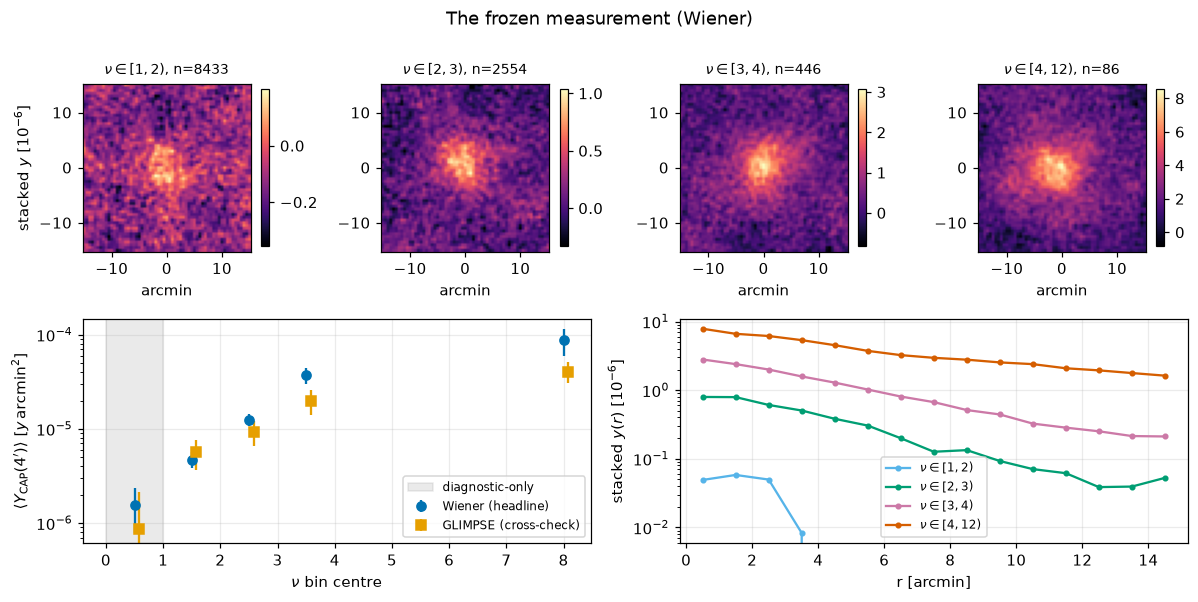

In [3]:
st_w = load("wp2_measurement/stack_wiener_sm2am_fid.npz")
st_g = load("wp2_measurement/stack_glimpse_sm2am_fid.npz")
edges = st_w["nu_edges"]; radii = st_w["cap_radii_arcmin"]; R4 = 2  # 4' index
FIT = slice(1, 5)  # nu >= 1 (the inference bins)

def snr(st):
    y = st["y_mean"][:, R4]; sig = np.sqrt(st["y_cov"][:, R4, R4])
    return y, sig, y / sig

yw, sw, snw = snr(st_w); yg, sg, sng = snr(st_g)
print(f"{'nu bin':>10} {'n':>6} {'<Y(4am)>':>11} {'S/N':>6}   (Wiener)")
for b in range(5):
    tag = "" if b else "  [diagnostic-only]"
    print(f"[{edges[b]:g},{edges[b+1]:g}) {st_w['n_per_bin'][b]:6d} "
          f"{yw[b]:11.3e} {snw[b]:6.1f}{tag}")
print(f"combined S/N (fit bins, Wiener) : {np.sqrt((snw[FIT]**2).sum()):.1f}")
print(f"combined S/N (fit bins, GLIMPSE): {np.sqrt((sng[FIT]**2).sum()):.1f}")

fig = plt.figure(figsize=(11, 5.4))
gs = fig.add_gridspec(2, 4, height_ratios=[1, 1.15])
ext = [-15.25, 15.25, -15.25, 15.25]
for i, b in enumerate(range(1, 5)):
    ax = fig.add_subplot(gs[0, i])
    im = ax.imshow(st_w["stacked_thumbs"][b] * 1e6, origin="lower", extent=ext,
                   cmap="magma")
    ax.set_title(rf"$\nu\in[{edges[b]:g},{edges[b+1]:g})$, n={st_w['n_per_bin'][b]}",
                 fontsize=9)
    ax.set_xlabel("arcmin"); ax.grid(False)
    if i == 0: ax.set_ylabel("stacked $y$ [$10^{-6}$]")
    plt.colorbar(im, ax=ax, shrink=0.8)
ax = fig.add_subplot(gs[1, :2])
c = 0.5 * (edges[:-1] + edges[1:])
ax.errorbar(c, yw, sw, fmt="o", color=OI["blue"], label="Wiener (headline)")
ax.errorbar(c + 0.08, yg, sg, fmt="s", color=OI["orange"], label="GLIMPSE (cross-check)")
ax.axvspan(edges[0], edges[1], color=OI["grey"], alpha=0.2, label="diagnostic-only")
ax.set(yscale="log", xlabel=r"$\nu$ bin centre",
       ylabel=r"$\langle Y_{\rm CAP}(4')\rangle$ [$y\,{\rm arcmin}^2$]")
ax.legend(fontsize=8)
ax = fig.add_subplot(gs[1, 2:])
for b, col in zip(range(1, 5), (OI["sky"], OI["green"], OI["purple"], OI["red"])):
    ax.plot(st_w["profiles_r_arcmin"], st_w["profiles"][b] * 1e6, "-o", ms=3,
            color=col, label=rf"$\nu\in[{edges[b]:g},{edges[b+1]:g})$")
ax.set(xlabel="r [arcmin]", ylabel=r"stacked $y(r)$ [$10^{-6}$]", yscale="log")
ax.legend(fontsize=8)
fig.suptitle("The frozen measurement (Wiener)", y=1.005)
fig.tight_layout(); fig.savefig(FIG / "fig2_measurement.png", bbox_inches="tight")
plt.show()

## 3. Null battery and the systematics budget $\Sigma_{\rm sys}$

Six pre-registered null/systematics tests (criteria fixed in writing before
execution): **S1** random-position ensembles (bias + width calibration of
the stacker), **S2** stability shifts across analysis choices, **S3**
B-mode-map peaks (must stack to zero signal), **S4** CIB-deprojected $y$-map
variants, **S5** mask-proximity dependence, **S6** ACT-threshold recuts.

**Decision — the $\Sigma_{\rm sys}$ convention.** The CIB deprojection
family moves the measurement coherently along a single direction in
$\nu$-bin space, so the adopted budget is a **rank-1 "decomposed" CIB term**
(half the fiducial↔deproj band, correlated across bins) rather than the
"strict" independent-per-bin envelope, which double-counts the same
systematic in every bin. Both are in the bundle; the fit's conclusion is
unchanged under either.

**Absolute photometry anchor.** The ACT DR5 cluster catalog stacked through
the *identical* thumbnail+CAP chain reproduces the expected cluster signal
(units + beam sanity; profile in the bundle). A fully independent external
photometric anchor remains on the systematics ladder (§6, item 5).

**Post-fit follow-up (ladder item 2).** DES stellar-density, PSF-residual
and SFD-dust covariate tests: tercile splits and 90%-excision recuts of the
frozen per-peak table — printed below.

scorecard sections: S1_ensemble_wiener, S1_ensemble_glimpse, S2_shifts, S3_bmode, S5_mask_proximity, S6_threshold, S4_cib_wiener, S4_cib_glimpse
star/PSF/dust follow-up: worst tercile |sigma| = 2.36 (consistent with trials), worst 90%-excision shift = 0.71 sigma_stat


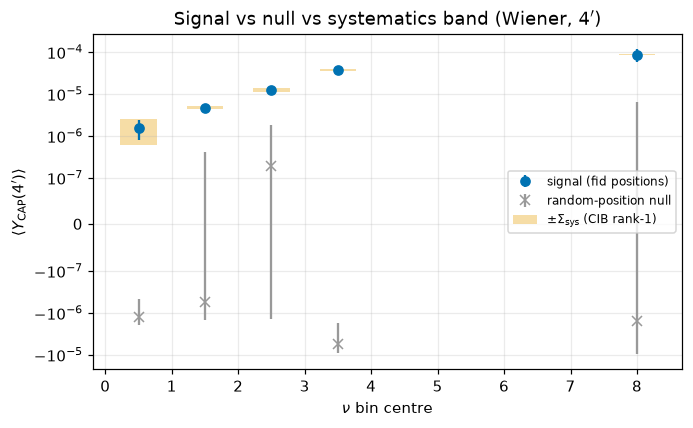

In [4]:
sc = load("wp3_nulls/b3_scorecard.json")
ss = load("wp3_nulls/sigma_sys_wiener_decomposed.npz")
sd = load("wp3_nulls/star_dust_summary.json")
nullpos = load("wp2_measurement/stack_wiener_sm2am_nullpos.npz")

print("scorecard sections:", ", ".join(k for k in sc if k != "criteria_doc"))
worst_t, worst_e = 0.0, 0.0
for key, d in sd.items():
    if key.endswith("_tercile"):
        worst_t = max(worst_t, max(abs(b["sigma"]) for b in d.values()))
    if key.endswith("_excision"):
        worst_e = max(worst_e, max(abs(b["delta_over_sigma_stat"])
                                   for k, b in d.items() if k.startswith("bin")))
print(f"star/PSF/dust follow-up: worst tercile |sigma| = {worst_t:.2f} "
      f"(consistent with trials), worst 90%-excision shift = {worst_e:.2f} sigma_stat")

fig, ax = plt.subplots(figsize=(6.4, 4))
c = 0.5 * (edges[:-1] + edges[1:])
ax.errorbar(c, yw, sw, fmt="o", color=OI["blue"], label="signal (fid positions)")
ax.errorbar(c, nullpos["y_mean"][:, R4], np.sqrt(nullpos["y_cov"][:, R4, R4]),
            fmt="x", color=OI["grey"], label="random-position null")
ax.bar(c, 2 * ss["half_band"], bottom=yw - ss["half_band"], width=0.55,
       color=OI["orange"], alpha=0.35, label=r"$\pm\Sigma_{\rm sys}$ (CIB rank-1)")
ax.set_yscale("symlog", linthresh=1e-7)
ax.set(xlabel=r"$\nu$ bin centre", ylabel=r"$\langle Y_{\rm CAP}(4')\rangle$")
ax.legend(fontsize=8); ax.set_title("Signal vs null vs systematics band (Wiener, 4$'$)")
fig.tight_layout(); fig.savefig(FIG / "fig3_nulls.png", bbox_inches="tight")
plt.show()

## 4. The forward model: a feedback-atlas grid observed like the data

**The atlas.** 60 mock-universe units spanning gas-ejection / heating
extremes (paired parameter bounds of a 30-parameter feedback model, painted
on TNG300-DMO lightcones with the BIND generative emulator; $\kappa$ and $y$
from the *same* realizations), plus the fiducial-parameter unit as the grid
anchor, plus a TNG300-hydro truth lightcone used only for selection
validation (never trained on). Each unit is reduced to the model table
coordinates $(\Delta\ln M_{\rm gas}, \Delta\ln T)$ — its gas-mass and
temperature offsets from fiducial.

**Survey realism, identical operators.** Mock $\kappa$: DES Y3 $n(z)$
source-plane weighting (weights + two scheme variants in the bundle), DES
shape noise ($n_{\rm eff}=5.59\,{\rm arcmin}^{-2},\ \sigma_e=0.261$) per
seed, then the transfer filter (below), then the *same* smoothing, peak
finder, $\nu$ normalization, thumbnail and CAP code as the data (no
data-only branches anywhere in the measurement path). Mock $y$: ACT $1.6'$
beam. **32 noise seeds per realization** — pre-registered after an 8-seed
interim run showed the Monte-Carlo tier tripping the selection-validation
tolerance statistically.

**Decision — the transfer-matched filter.** The data peaks live in a
*reconstructed* (Wiener/GLIMPSE-filtered) map; intrinsic mock $\kappa$ has a
different 2-pt content, which biases matched-$\nu$ selection. We apply an
empirical transfer $T(\ell) = \sqrt{C_\ell^{\rm data}/C_\ell^{\rm mock}}$
(per variant, derived from $\kappa$ two-point statistics **only** — the $y$
channel is never touched, so the stacked observable is not tuned) to the
noisy mock $\kappa$. The alternative — quantile-matching mock $\nu$ to data
$\nu$ — was **rejected** because it forces the mock peak *abundance* to
equal the data's by construction, erasing the abundance channel this
analysis needs. Validation: the $\nu\ge4$ mock abundance closes from
$5.4\times$ off to $1.36\times$ after the transfer.

**Decision — coarse-grid peak finding.** Data peaks are found on the
$3.44'$ HEALPix grid, which *merges* nearby maxima. The matched convention
finds mock peaks on a block-averaged coarse grid of the same pitch
(supersedes position-snapping, which cannot merge maxima). This is ladder
item 1 in §6.

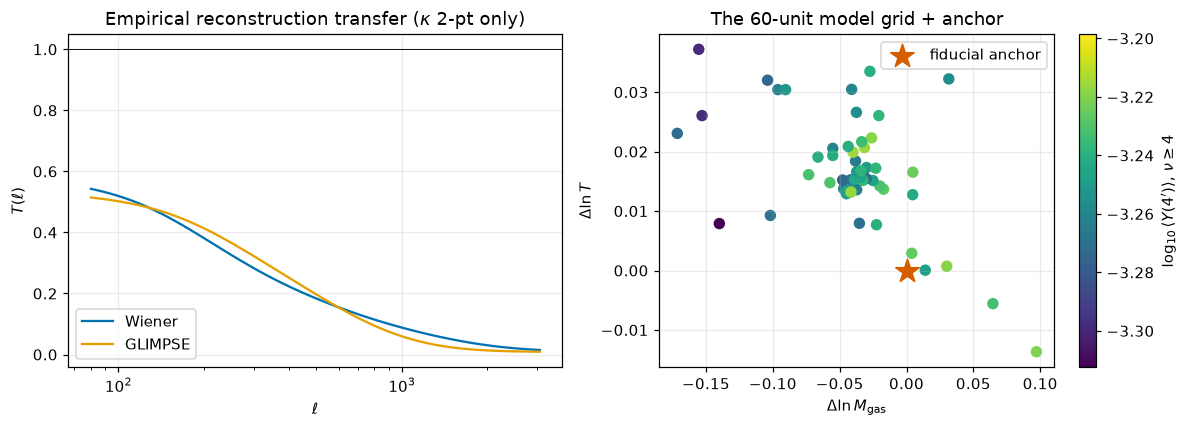

nu>=4 abundance closure: mock {'mock_unfiltered': 0.105, 'data_wiener': 0.019607296127010405, 'mock_tfwiener': 0.02666666666666667, 'data_glimpse': 0.0613297983507651, 'mock_tfglimpse': 0.021666666666666667}, data Wiener n=86 over 4386 deg^2


In [5]:
tf = load("wp4_mocks/transfer_desy3.npz")
grid = load("wp4_mocks/model_grid_tfwiener.npz")
anchor = load("wp4_mocks/grid_tfwiener/bind_run_0000.npz")
tsum = load("wp4_mocks/b5_transfer_summary.json")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(tf["ell_wiener"], tf["t_wiener"], color=OI["blue"], label="Wiener")
axes[0].plot(tf["ell_glimpse"], tf["t_glimpse"], color=OI["orange"], label="GLIMPSE")
axes[0].axhline(1, color="k", lw=0.6)
axes[0].set(xscale="log", xlabel=r"$\ell$", ylabel=r"$T(\ell)$",
            title="Empirical reconstruction transfer ($\\kappa$ 2-pt only)")
axes[0].legend()
sc_ = axes[1].scatter(grid["delta_ln_mgas"], grid["delta_ln_t"],
                      c=np.log10(grid["y_mean"][:, 4, R4]), cmap="viridis", s=42)
axes[1].scatter([0], [0], marker="*", s=260, color=OI["red"], zorder=5,
                label="fiducial anchor")
plt.colorbar(sc_, ax=axes[1], label=r"$\log_{10}\langle Y(4')\rangle$, $\nu\geq4$")
axes[1].set(xlabel=r"$\Delta\ln M_{\rm gas}$", ylabel=r"$\Delta\ln T$",
            title="The 60-unit model grid + anchor")
axes[1].legend()
fig.tight_layout(); fig.savefig(FIG / "fig4_forward_model.png", bbox_inches="tight")
plt.show()
print(f"nu>=4 abundance closure: mock {tsum['abundance_nu4_per_deg2']}, "
      f"data Wiener n={tsum['n_peaks_nu4_data_wiener']} "
      f"over {tsum['area_deg2_common_binary']:.0f} deg^2")

## 5. Inference: the data reject the entire model manifold

**Model layer.** One exact Gaussian process per $\nu$ bin interpolates
$\log_{10}\langle Y\rangle$ over $(\Delta\ln M_{\rm gas}, \Delta\ln T)$
across the 61 units, with per-point noise from the grid Monte-Carlo errors.
Leave-one-out over all 61 units: median $|$rel. err$|$ per bin
$\approx[0.9, 1.0, 1.5, 2.7]\%$ with pull widths $\approx 1$ — interpolation
error is subdominant and the GP's own error model is calibrated.

**Covariance tiers**: jackknife statistics $\oplus$ $\Sigma_{\rm sys}$
(rank-1 CIB) $\oplus$ selection residual (from the selection-validation
ratios) $\oplus$ GP predictive variance (grid-MC + interpolation).

**Blinding discipline.** The injection-recovery gate (coverage of known
inputs across the grid, including edge regimes) ran and passed **before**
the data vector ever met the model. The model freeze was countersigned, the
fit ran once, and everything after is labelled post-unblinding in the
release records (`b5_hunt_record.json` preserves the ordering).

**Result.** The frozen data vector is rejected by the *entire* frozen model
manifold — a many-$\sigma$ rejection for 4 degrees of freedom (the cell
below recomputes a transparent diagonal $\chi^2$ against every sampled unit
and prints the recorded diagnostics from the release fit record). The data
sit a factor $\sim3$ below the fiducial model in the $\nu\in[1,4)$ bins and
$\sim6\times$ below in $\nu\ge4$; the posterior piles at the
low-$M_{\rm gas}$ window corner, so the fit is reported as a **lower bound
in the gas-ejection direction**, not a parameter measurement.

recovery gate: pass=True (68% coverage 0.67, 95% 0.93)
diagonal chi2 recomputed here (sigma_total from the fit record): sampled-grid min = 506/4 (twobound/run_0013); fiducial anchor = 741/4
recorded release diagnostics (their own sigma recipe): chi2_fiducial_diag = 513, with cross-bin covariance = 488 (off-diagonals do not rescue the fit)
data/model(anchor) at 4': [0.313 0.315 0.282 0.147]
posterior MAP = [-0.35, -0.03], window-edge mass = 0.78


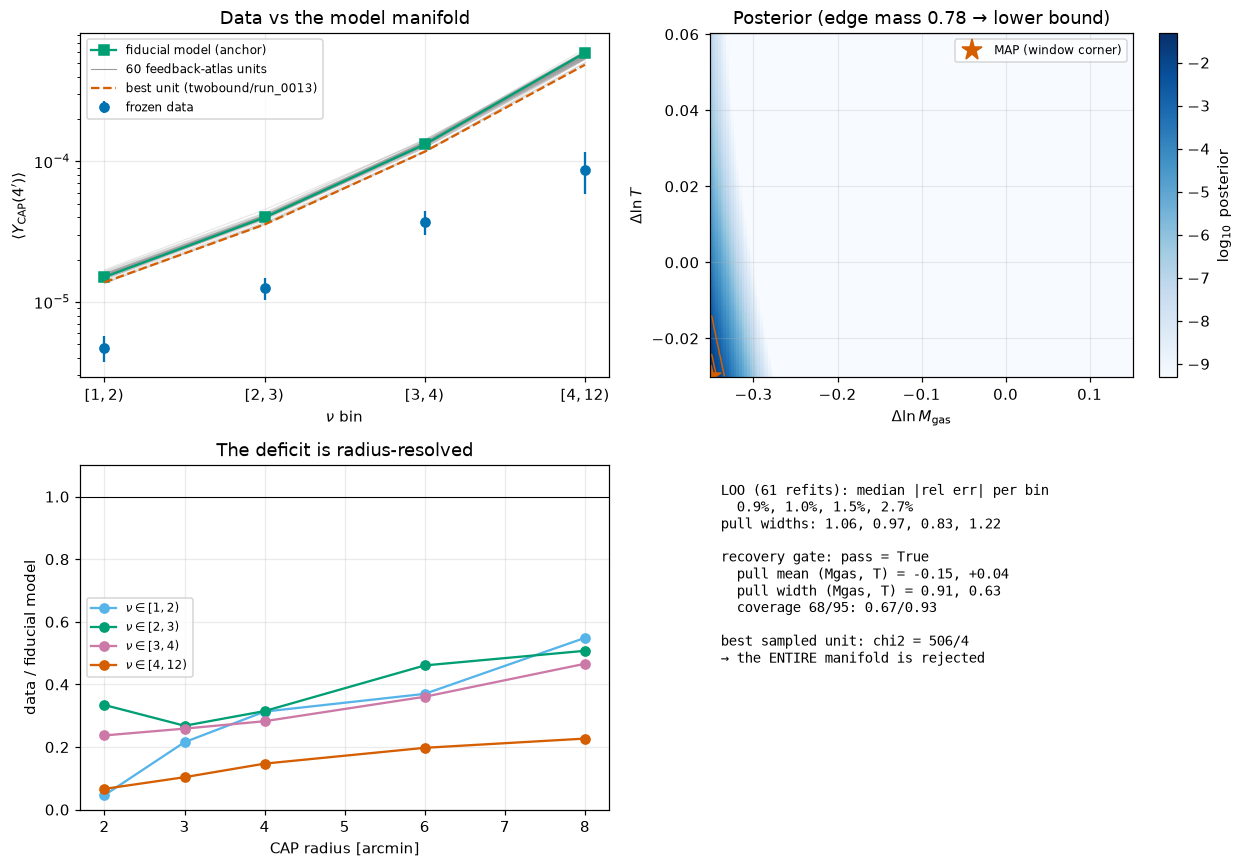

In [6]:
loo = load("wp5_inference/b5_loo.json")
rec = load("wp5_inference/b5_recovery.json")
fit = load("wp5_inference/b5_fit_wiener.json")
post = load("wp5_inference/b5_posterior_wiener.npz")

y_data = np.asarray(fit["y_data"]); sig_tot = np.asarray(fit["sigma_total"])
assert np.allclose(y_data, st_w["y_mean"][FIT, R4])   # frozen vector == stack
ym_a = anchor["y_mean"]

# chi2 of every grid unit + the anchor against the frozen vector
units_y = np.vstack([grid["y_mean"][:, 1:5, R4], ym_a[None, 1:5, R4]])
chi2 = ((units_y - y_data) ** 2 / sig_tot ** 2).sum(axis=1)
best = int(np.argmin(chi2))
best_name = (str(grid["run_names"][best]) if best < len(grid["run_names"])
             else "fiducial anchor")
hunt = load("wp5_inference/b5_hunt_record.json")
print(f"recovery gate: pass={rec['pass']} (68% coverage "
      f"{rec['coverage_68']:.2f}, 95% {rec['coverage_95']:.2f})")
print(f"diagonal chi2 recomputed here (sigma_total from the fit record): "
      f"sampled-grid min = {chi2.min():.0f}/4 ({best_name}); "
      f"fiducial anchor = {chi2[-1]:.0f}/4")
print(f"recorded release diagnostics (their own sigma recipe): "
      f"chi2_fiducial_diag = {hunt['chi2_fiducial_diag']:.0f}, "
      f"with cross-bin covariance = {hunt['chi2_fiducial_crossbin']:.0f} "
      f"(off-diagonals do not rescue the fit)")
print("data/model(anchor) at 4':",
      np.round(y_data / ym_a[1:5, R4], 3))
assert np.allclose(np.asarray(hunt["data_over_model_by_radius"])[1:5, R4],
                   y_data / ym_a[1:5, R4], atol=5e-3)  # matches the release record
print(f"posterior MAP = {fit['map']}, window-edge mass = {fit['edge_mass']:.2f}")

fig = plt.figure(figsize=(11.5, 8))
gs = fig.add_gridspec(2, 2)
xb = np.arange(4)
xlabels = [rf"$[{edges[b]:g},{edges[b+1]:g})$" for b in range(1, 5)]
ax = fig.add_subplot(gs[0, 0])
ax.errorbar(xb, y_data, sig_tot, fmt="o", color=OI["blue"], zorder=5, label="frozen data")
ax.plot(xb, ym_a[1:5, R4], "-s", color=OI["green"], label="fiducial model (anchor)")
for i in range(60):
    ax.plot(xb, grid["y_mean"][i, 1:5, R4], color=OI["grey"], alpha=0.25, lw=0.7,
            zorder=1)
ax.plot([], [], color=OI["grey"], lw=0.7, label="60 feedback-atlas units")
ax.plot(xb, units_y[best], "--", color=OI["red"], label=f"best unit ({best_name})")
ax.set(yscale="log", xticks=xb, xticklabels=xlabels, xlabel=r"$\nu$ bin",
       ylabel=r"$\langle Y_{\rm CAP}(4')\rangle$", title="Data vs the model manifold")
ax.legend(fontsize=8)
ax = fig.add_subplot(gs[0, 1])
P = post["posterior"]; mg, dt = post["mg"], post["dt"]
logP = np.log10(np.maximum(P, P.max() * 1e-12))
im = ax.pcolormesh(mg, dt, logP.T, cmap="Blues", shading="auto",
                   vmin=logP.max() - 8)
plt.colorbar(im, ax=ax, label=r"$\log_{10}$ posterior")
lv = sorted(P.max() * np.exp(-0.5 * np.array([2.30, 6.18])))
ax.contour(mg, dt, P.T, levels=lv, colors=[OI["red"]], linewidths=1)
ax.plot(*fit["map"], "*", ms=14, color=OI["red"], label="MAP (window corner)")
ax.legend(fontsize=8, loc="upper right")
ax.set(xlabel=r"$\Delta\ln M_{\rm gas}$", ylabel=r"$\Delta\ln T$",
       title=f"Posterior (edge mass {fit['edge_mass']:.2f} → lower bound)")
ax = fig.add_subplot(gs[1, 0])
for b, col in zip(range(1, 5), (OI["sky"], OI["green"], OI["purple"], OI["red"])):
    ax.plot(radii, st_w["y_mean"][b] / ym_a[b], "-o", color=col,
            label=rf"$\nu\in[{edges[b]:g},{edges[b+1]:g})$")
ax.axhline(1, color="k", lw=0.7)
ax.set(xlabel="CAP radius [arcmin]", ylabel="data / fiducial model",
       title="The deficit is radius-resolved", ylim=(0, 1.1))
ax.legend(fontsize=8)
ax = fig.add_subplot(gs[1, 1])
med = ", ".join(f"{v*100:.1f}%" for v in loo["median_abs_rel"])
pw = ", ".join(f"{v:.2f}" for v in loo["pull_std"])
txt = (f"LOO (61 refits): median |rel err| per bin\n"
       f"  {med}\n"
       f"pull widths: {pw}\n\n"
       f"recovery gate: pass = {rec['pass']}\n"
       f"  pull mean (Mgas, T) = "
       + ", ".join(f"{v:+.2f}" for v in rec["pull_mean"]) + "\n"
       f"  pull width (Mgas, T) = "
       + ", ".join(f"{v:.2f}" for v in rec["pull_std"]) + "\n"
       f"  coverage 68/95: {rec['coverage_68']:.2f}/{rec['coverage_95']:.2f}\n\n"
       f"best sampled unit: chi2 = {chi2.min():.0f}/4\n"
       f"→ the ENTIRE manifold is rejected")
ax.text(0.02, 0.95, txt, va="top", family="monospace", fontsize=9)
ax.axis("off")
fig.tight_layout(); fig.savefig(FIG / "fig5_inference.png", bbox_inches="tight")
plt.show()

## 6. The interpretation ladder: exhausting systematics before physics

The rejection fired a pre-registered tripwire, so a systematics **ladder**
was worked through *before* any physical claim — each rung a specific
mechanism that could fake a $y$-deficit, with its verdict recorded:

1. **Selection-grid convention** (coarse-pixel peak *finding*): the full
   grid re-ran under the matched coarse-finding convention — the fiducial
   data/model ratios are unchanged. **Null.**
2. **Star/PSF/dust covariates**: tercile splits and 90%-excisions of the
   frozen tables (§3 numbers) — orders of magnitude too small. **Null.**
3. **Reconstruction positional scatter** beyond the modeled shape noise +
   quantization: a dilution analysis (required scatter vs available
   bounds). **Cannot be the full explanation** — the required scatter
   *grows* with peak significance while any noise-driven scatter shrinks,
   and the large-aperture deficit survives all credits — but a bounded
   partial contribution ($\lesssim2\times$ in the mid bins) is not
   excluded and is carried as a nuisance in the interpretation.
4. **Transfer-shape robustness**: the grid re-run with transfer shapes
   derived from different atlas denominators moves the prediction by
   $\le 8\%$ (movement numbers below) — an order of magnitude too small.
   **Null.**
5. **Absolute photometric anchor**: the same map product, CAP filter and
   units were used by an independent group (Liu et al. 2025,
   arXiv:2502.08850) to stack DESI DR9 Main-LRG positions; we repeat
   their measurement with *our* pipeline on the public catalog (official
   quality cuts) and compare amplitudes — an end-to-end absolute check of
   the $y$-map handling, beam, units and CAP code, independent of the DES
   peak chain. (Their Zenodo release carries a column-replication bug —
   every pz/variant column holds the same series — so the comparison also
   serves as an identification test against the one genuine series.)
   **Executed at full depth (120k/bin, all four bins): the identification
   test is decisively negative** — every bin shows the same
   cumulative-vs-hump radius signature against the one genuine series
   ($\chi^2$ = 376/191/139/94 per 9), confirming the released series is
   plausibly from a differential (non-cumulative) figure family. The
   released vectors are therefore unusable as an absolute anchor in any
   column; our four measured profiles are retained for comparison against
   author-confirmed vectors. **Inconclusive by external bug — the
   absolute-amplitude guard remains open.**
6. **$\sigma_8$/cosmology bracket**: open (estimated second-order, since
   the transfer re-matches the two-point content by construction).
7. **Shear multiplicative bias**: cancels **exactly** — every step is
   linear in the map and $\nu$ is self-normalized on both the data and
   mock sides; demonstrated at $|m|=0.03$ with machine-precision closure.
   **Null-exact.**
8. **Manifold-coverage extension (Sobol box)**: the frozen grid samples
   the two-parameter $(\Delta\ln M_{\rm gas}, \Delta\ln T)$ family along
   axis extremes — could parameter *interactions* in the full 30-dim
   feedback prior open an escape route? All 253 runs of the SB35 Sobol
   suite (same shared-DMO realizations) were pushed through the identical
   transfer-matched chain. **Pre-registered verdict (criterion fixed
   before any model vector was seen): $\chi^2_{\min} = 340/4$ over the
   full box — zero of 253 units below the rejection threshold of 100.
   The rejection extends to the full sampled 30-dim box.** Even the best
   unit (the extreme ejection corner, $\Delta\ln M_{\rm gas} = -0.31$)
   leaves data/model at 0.40/0.41/0.36/0.21.

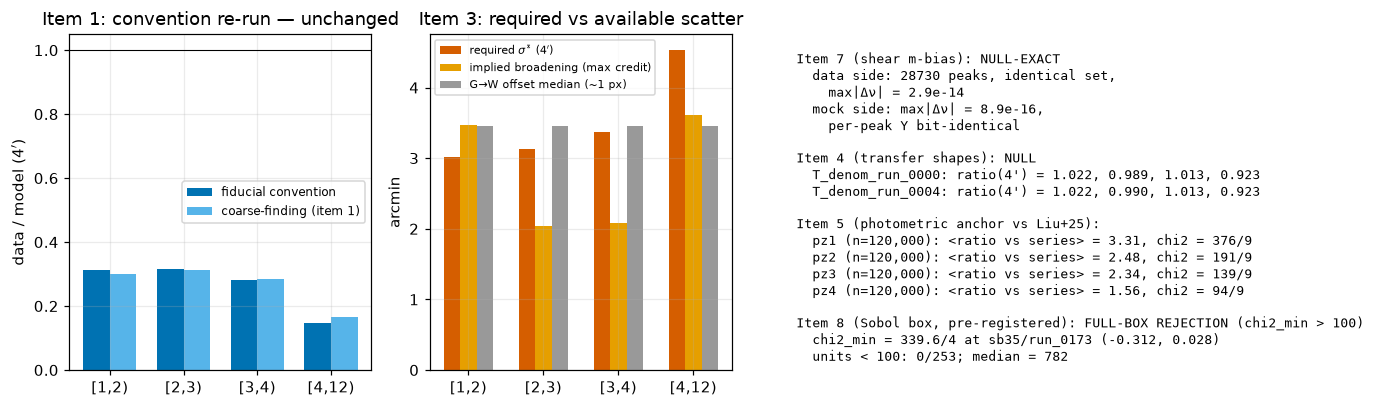

residual data/model after MAXIMAL scatter credit, 8' aperture: [0.79, 0.56, 0.52, 0.34]


In [7]:
fit_pg = load("wp5_inference/b5_fit_wiener_pg1024.json")
anchor_pg = load("wp4_mocks/grid_tfwiener_pg1024/bind_run_0000.npz")
ps = load("wp5_inference/posscatter/posscatter_summary.json")
mb = load("wp5_inference/mbias/mbias_summary.json")
mv = load("wp5_inference/transfer_movement.json")

r_fid = y_data / ym_a[1:5, R4]
r_pg = np.asarray(fit_pg["y_data"]) / anchor_pg["y_mean"][1:5, R4]
labels = [f"[{edges[b]:g},{edges[b+1]:g})" for b in range(1, 5)]

req = [ps["bins"][k]["model_capfit"]["sigma_at_4am"] for k in ps["bins"]]
impl = [ps["bins"][k]["implied_broadening_arcmin"] for k in ps["bins"]]
gw = [ps["glimpse_to_wiener_offsets"][k]["median_arcmin"]
      for k in ps["glimpse_to_wiener_offsets"]]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
x = np.arange(4)
axes[0].bar(x - 0.18, r_fid, 0.36, color=OI["blue"], label="fiducial convention")
axes[0].bar(x + 0.18, r_pg, 0.36, color=OI["sky"], label="coarse-finding (item 1)")
axes[0].axhline(1, color="k", lw=0.7)
axes[0].set(xticks=x, xticklabels=labels, ylabel="data / model (4$'$)",
            title="Item 1: convention re-run — unchanged")
axes[0].legend(fontsize=8)
axes[1].bar(x - 0.22, req, 0.22, color=OI["red"], label=r"required $\sigma^*$ (4$'$)")
axes[1].bar(x, impl, 0.22, color=OI["orange"], label="implied broadening (max credit)")
axes[1].bar(x + 0.22, gw, 0.22, color=OI["grey"], label="G→W offset median (~1 px)")
axes[1].set(xticks=x, xticklabels=labels, ylabel="arcmin",
            title="Item 3: required vs available scatter")
axes[1].legend(fontsize=7)
mtxt = (f"Item 7 (shear m-bias): NULL-EXACT\n"
        f"  data side: {mb['data_side']['n_peaks']} peaks, identical set,\n"
        f"    max|Δν| = {mb['data_side']['max_abs_delta_nu']:.1e}\n"
        f"  mock side: max|Δν| = {mb['model_side']['max_abs_delta_nu']:.1e},\n"
        f"    per-peak Y bit-identical\n\nItem 4 (transfer shapes): NULL\n")
for name, v in mv["variants"].items():
    mtxt += (f"  {name}: ratio(4') = "
             + ", ".join(f"{r:.3f}" for r in v["ratio_4am"]) + "\n"
             if v.get("status") == "ok" else f"  {name}: grids running\n")
try:
    pa = load("wp5_inference/photo_anchor/photo_anchor_summary.json")
    mtxt += "\nItem 5 (photometric anchor vs Liu+25):\n"
    for k, r in pa["bins"].items():
        if "ratio_to_liu_series" in r:
            mtxt += (f"  {k} (n={r['n_stacked']:,}): "
                     f"<ratio vs series> = "
                     f"{np.mean(r['ratio_to_liu_series']):.2f}, "
                     f"chi2 = {r['chi2_vs_liu_series']:.0f}/9\n")
except (KeyError, FileNotFoundError):
    mtxt += "\nItem 5 (photometric anchor): measurement in progress\n"
try:
    sv = load("wp4_mocks/sobol/b5_sobol_verdict.json")
    mtxt += (f"\nItem 8 (Sobol box, pre-registered): {sv['verdict']}\n"
             f"  chi2_min = {sv['chi2_min']:.1f}/4 at {sv['chi2_min_at']}"
             f" {tuple(round(c,3) for c in sv['chi2_min_coords'])}\n"
             f"  units < 100: {sv['n_below_100']}/{sv['n_units']};"
             f" median = {sv['chi2_median']:.0f}\n")
except (KeyError, FileNotFoundError):
    mtxt += "\nItem 8 (Sobol box): grids running\n"
axes[2].text(0.02, 0.95, mtxt, va="top", family="monospace", fontsize=8.5)
axes[2].axis("off")
fig.tight_layout(); fig.savefig(FIG / "fig6_ladder.png", bbox_inches="tight")
plt.show()
print("residual data/model after MAXIMAL scatter credit, 8' aperture:",
      [round(ps["bins"][k]["residual_ratio_after_full_credit_per_radius"][-1], 2)
       for k in ps["bins"]])

## 7. Reproducibility appendix

**What ran where.** Map downloads, peak finding, the 23k-peak stacks and
the null battery ran as CPU passes; the mock grids ran as Slurm jobs on the
Flatiron *Popeye* cluster — intrinsic grid **2451467**, transfer-matched
FINAL grid (n_seeds = 32), coarse-finding variant **2451611**,
transfer-shape variants **2451614 / 2451615**, the 253-run Sobol-box
extension **2451635**, and the photometric-anchor stack **2451638**. The
fit and ladder analyses are CPU-light and re-runnable.

**Code.** `analysis/paper3b/` in the BIND repository
(github.com/Maxelee/BIND): `maps/` (loaders, footprint, peak finder),
`stack/` (thumbnails, CAP, jackknife, the hash-gated frozen loader),
`mocks/` (n(z) weighting, shape noise, transfer, beam, the mock measurement
chain), `inference/` (grid table, GP, likelihood, recovery), `scripts/`
(every runner used above). The package test suite covers the operator code
(84 tests at release).

**Full bundle manifest** (sha256-pinned):

In [8]:
print(f"{'file':58s} {'kB':>8}  sha256[:12]  description")
for rel, m in MANIFEST["files"].items():
    print(f"{rel:58s} {m['bytes']/1e3:8.1f}  {m['sha256'][:12]}  {m['description'][:60]}")

file                                                             kB  sha256[:12]  description
wp1_maps/common_footprint_nside1024.npz                       323.5  be9bb1915824  Harmonized DES Y3 x ACT DR6 footprint: apodized weight + con
wp1_maps/peaks_wiener_sm2am.npz                               628.8  597cd0025737  Frozen Wiener peak catalog at the fiducial 2' smoothing (pos
wp1_maps/peaks_glimpse_sm2am.npz                              210.5  d2cd36fbc6ed  GLIMPSE cross-check peak catalog at 2' smoothing
wp1_maps/peaks_wiener_sm1am.npz                               804.7  7c37b986c714  Wiener peaks, 1' robustness smoothing
wp1_maps/peaks_wiener_sm5am.npz                               203.9  64acf5f2056f  Wiener peaks, 5' robustness smoothing
wp1_maps/peaks_wiener_sm8am.npz                                74.8  4ee9d5fad569  Wiener peaks, 8' robustness smoothing
wp1_maps/peaks_glimpse_sm1am.npz                              274.6  ce0319b964bd  GLIMPSE peaks, 1' robustness smoothing
w